# Tarea 5

**Autor:** Alejandro Zarate Macias  

**Curso:** Reconocimiento de Patrones (ML)

**Fecha:** 2 de Marzo 2026

---

## Introducción

Estos ejercicios tienen como objetivo revisar algunos modelos de aprendizaje no supervisado.

---

## Pre-requisitos

- Python 3.9 o superior
- Librerías:
    - numpy
    - matplotlib
    - notebook
    - pandas
    - scikit-learn
    - kagglehub[pandas-datasets]

---

# Problema 3

Considere el dataset de `divorce_data`. A continuación:

a) Resuelva el problema de clasificación.

b) Identifique las características más relevantes para la clasificación. El objetivo aquí es reducir el número de características empleadas manteniendo una alta precisión de clasificación.

Anote todos sus supuestos y discuta sus hallazgos.

### Librerias

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)


### Carga de datos

In [2]:
# Descarga de datos
file = "divorce_data.csv"

path = kagglehub.dataset_download("andrewmvd/divorce-prediction")
df3 = pd.read_csv(os.path.join(path, file), sep=";")


In [3]:
pd.set_option('display.max_columns', None)
df3.head()


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Divorce
0,2,2,4,1,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,2,1,2,0,1,2,1,3,3,2,1,1,2,3,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,4,3,4,0,4,4,4,4,3,2,1,1,0,2,2,1,2,0,1,1,0,4,2,3,0,2,3,4,2,4,2,2,3,4,2,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,3,4,2,3,3,3,3,3,3,2,1,0,1,2,2,2,2,2,3,2,3,3,1,1,1,1,2,1,3,3,3,3,2,3,2,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,4,3,3,4,3,3,3,3,3,4,1,1,1,1,2,1,1,1,1,3,2,3,2,2,1,1,3,3,4,4,2,2,3,2,3,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,0,1,0,1,1,1,1,1,2,1,1,0,0,0,0,2,1,2,1,1,1,1,1,1,0,0,0,0,2,1,0,2,3,0,2,2,1,2,3,2,2,2,1,0,1


In [4]:
df3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 55 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Q1       170 non-null    int64
 1   Q2       170 non-null    int64
 2   Q3       170 non-null    int64
 3   Q4       170 non-null    int64
 4   Q5       170 non-null    int64
 5   Q6       170 non-null    int64
 6   Q7       170 non-null    int64
 7   Q8       170 non-null    int64
 8   Q9       170 non-null    int64
 9   Q10      170 non-null    int64
 10  Q11      170 non-null    int64
 11  Q12      170 non-null    int64
 12  Q13      170 non-null    int64
 13  Q14      170 non-null    int64
 14  Q15      170 non-null    int64
 15  Q16      170 non-null    int64
 16  Q17      170 non-null    int64
 17  Q18      170 non-null    int64
 18  Q19      170 non-null    int64
 19  Q20      170 non-null    int64
 20  Q21      170 non-null    int64
 21  Q22      170 non-null    int64
 22  Q23      170 non-null    i

### Preprocesamiento de datos

In [5]:
# Separacion de features y etiquetas
X = df3.drop(columns=['Divorce']).values
y = df3['Divorce'].values

# Escalamiento de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=14, stratify=y
)


### Entrenamiento - Baseline

In [6]:
# Lista de modelos para la clasificacion
models = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'NN':            MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                   random_state=14),
    'SVM':           SVC(kernel='rbf', C=1.0, random_state=14),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=14),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10,
                                            random_state=14, n_jobs=-1),
}


In [7]:
# Entrenamiento y evaluacion de cada modelo
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'acc':  accuracy_score(y_test, y_pred),
        'f1':   f1_score(y_test, y_pred, average='weighted'),
        'pred': y_pred,
    }
    print("-"*60)
    print(name)
    print("-"*60)
    print(classification_report(y_test, y_pred, target_names=['Casado', 'Divorciado']))


------------------------------------------------------------
KNN
------------------------------------------------------------
              precision    recall  f1-score   support

      Casado       0.94      1.00      0.97        17
  Divorciado       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

------------------------------------------------------------
NN
------------------------------------------------------------
              precision    recall  f1-score   support

      Casado       0.94      1.00      0.97        17
  Divorciado       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

------------------------------------------------------------
SVM
------------------------------

### Entrenamiento - Feature Selection

In [8]:
# Feature Selection con RFE usando RandomForest para rankear las caracteristicas
feature_names = df3.drop(columns=['Divorce']).columns.tolist()

rfe_ranker = RFE(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=14, n_jobs=-1),
    n_features_to_select=1,
    step=1
)
rfe_ranker.fit(X_train, y_train)

# Calculo de importancia normalizada a partir del ranking
ranking = pd.Series(rfe_ranker.ranking_, index=feature_names).sort_values()
importance = (1 / ranking).sort_values(ascending=False)
importance_norm = importance / importance.sum()

top10_features = ranking.head(10).index.tolist()
print(f"Top 10 características seleccionadas por RFE:\n{top10_features}")


Top 10 características seleccionadas por RFE:
['Q40', 'Q18', 'Q17', 'Q20', 'Q19', 'Q9', 'Q11', 'Q16', 'Q26', 'Q36']


In [9]:
# Subconjunto de datos con las top 10 features seleccionadas por RFE
top10_idx = [feature_names.index(f) for f in top10_features]
X_train_10 = X_train[:, top10_idx]
X_test_10  = X_test[:, top10_idx]


In [10]:
# Lista de modelos para entrenamiento con top 10 features
models_10 = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'NN':            MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=14),
    'SVM':           SVC(kernel='rbf', C=1.0, random_state=14),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=14),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=14, n_jobs=-1),
}


In [11]:
# Entrenamiento y evaluacion con top 10 features
results_10 = {}
for name, clf in models_10.items():
    clf.fit(X_train_10, y_train)
    y_pred = clf.predict(X_test_10)
    results_10[name] = {
        'acc':  accuracy_score(y_test, y_pred),
        'f1':   f1_score(y_test, y_pred, average='weighted'),
        'pred': y_pred,
    }
    print("-"*60)
    print(f"{name}  (top 10 features)")
    print("-"*60)
    print(classification_report(y_test, y_pred, target_names=['Casado', 'Divorciado']))


------------------------------------------------------------
KNN  (top 10 features)
------------------------------------------------------------
              precision    recall  f1-score   support

      Casado       0.94      1.00      0.97        17
  Divorciado       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

------------------------------------------------------------
NN  (top 10 features)
------------------------------------------------------------
              precision    recall  f1-score   support

      Casado       0.94      1.00      0.97        17
  Divorciado       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

---------------------------------------------------------

### Evaluacion - Feature Selection

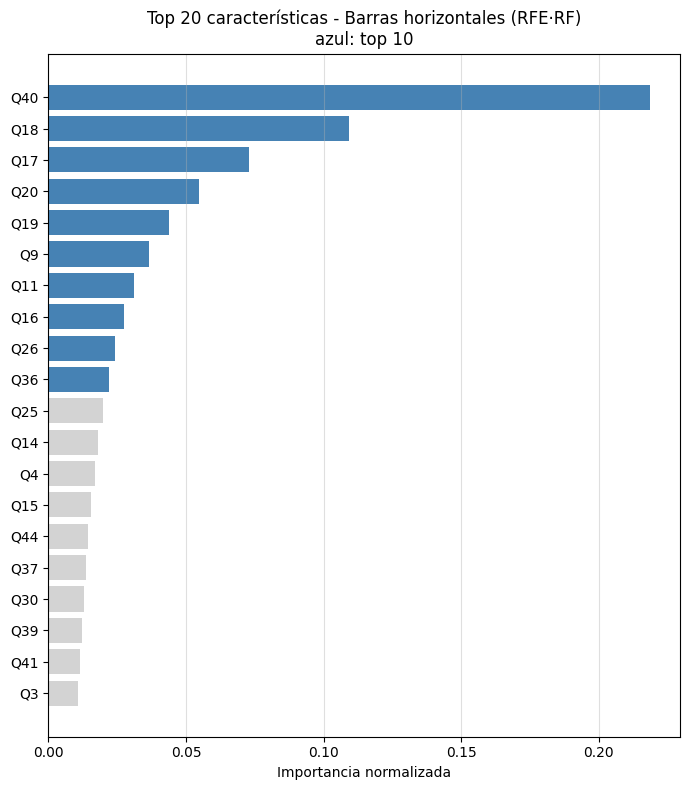

In [12]:
# Grafica de importancia normalizada de las top 20 features
top20 = importance_norm.head(20)
colors = ['steelblue' if f in top10_features else 'lightgray' for f in top20.index]

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('Importancia normalizada')
ax.set_title('Top 20 características - Barras horizontales (RFE·RF)\nazul: top 10')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


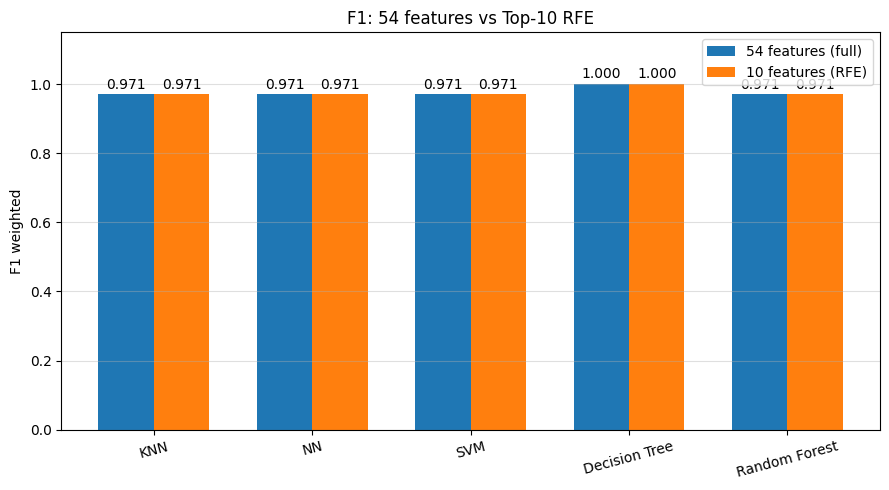

In [13]:
# Comparacion de F1: todas las features vs top 10 (RFE)
names = list(results.keys())
f1_full = [results[n]['f1']    for n in names]
f1_10   = [results_10[n]['f1'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, f1_full, width, label='54 features (full)')
bars2 = ax.bar(x + width/2, f1_10,   width, label='10 features (RFE)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 weighted')
ax.set_title('F1: 54 features vs Top-10 RFE')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2)
ax.bar_label(bars2, fmt='%.3f', padding=2)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


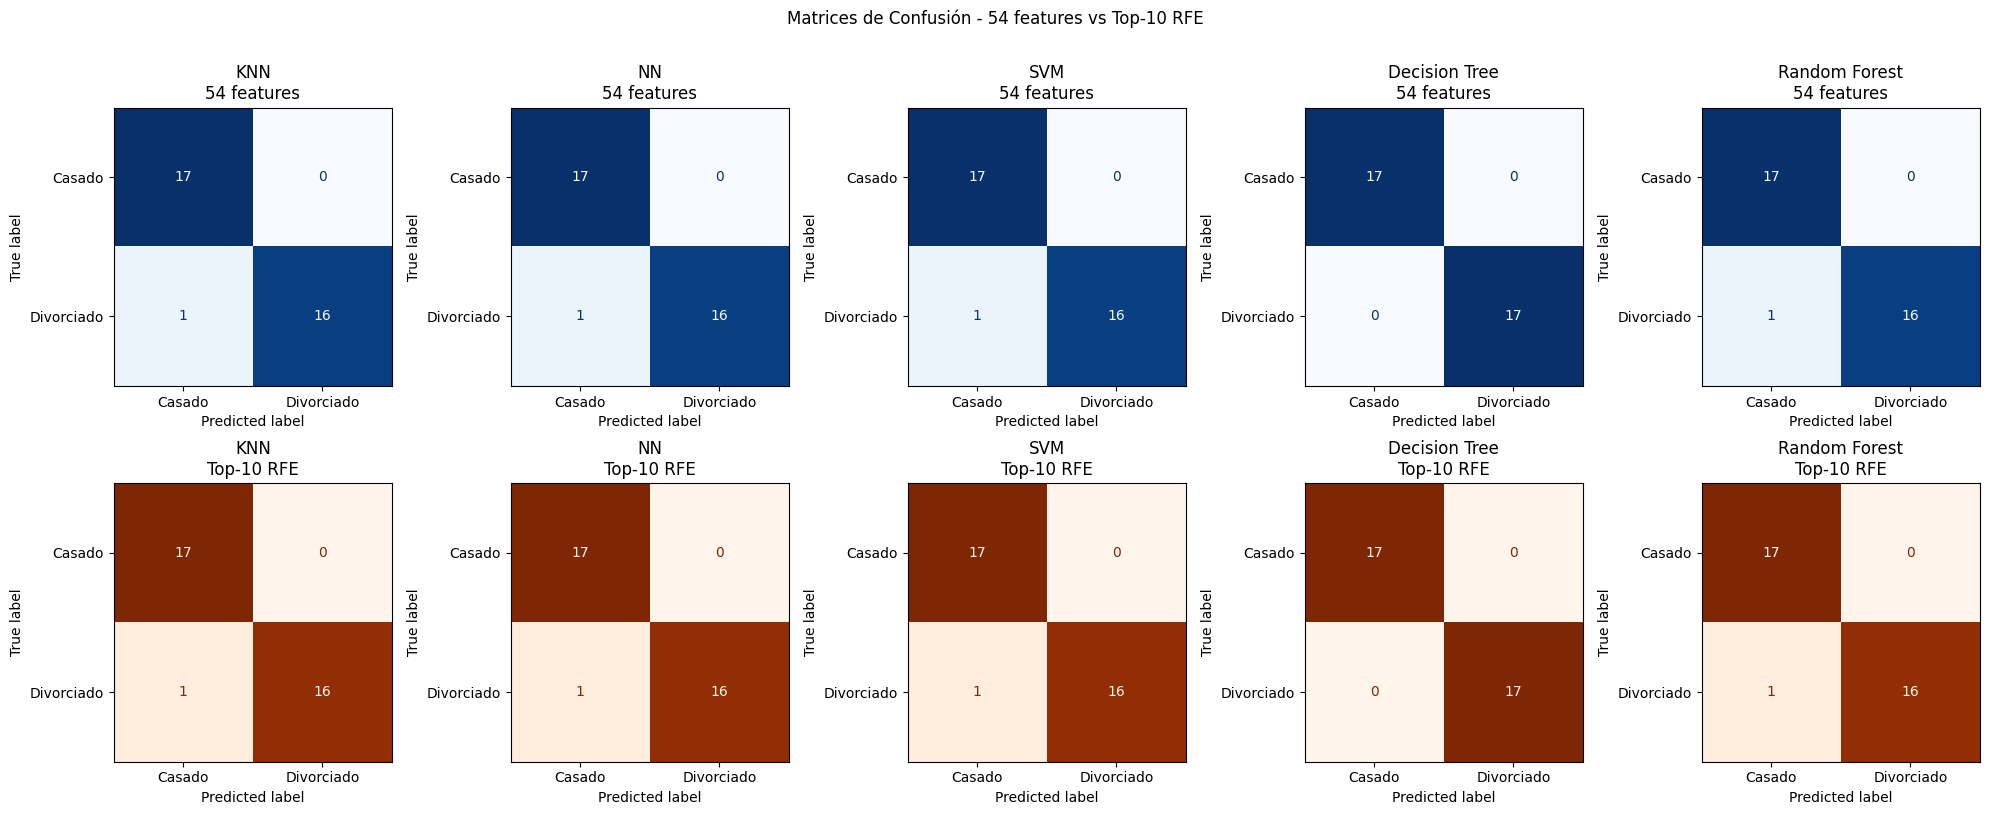

In [14]:
# Matrices de confusion: todas las features vs top 10 (RFE)
fig, axes = plt.subplots(2, len(names), figsize=(4 * len(names), 8))
for j, name in enumerate(names):
    cm_full = confusion_matrix(y_test, results[name]['pred'])
    ConfusionMatrixDisplay(cm_full, display_labels=['Casado', 'Divorciado']).plot(
        ax=axes[0, j], cmap='Blues', colorbar=False)
    axes[0, j].set_title(f'{name}\n54 features')

    cm_10 = confusion_matrix(y_test, results_10[name]['pred'])
    ConfusionMatrixDisplay(cm_10, display_labels=['Casado', 'Divorciado']).plot(
        ax=axes[1, j], cmap='Oranges', colorbar=False)
    axes[1, j].set_title(f'{name}\nTop-10 RFE')

plt.suptitle('Matrices de Confusión - 54 features vs Top-10 RFE', y=1.01)
plt.tight_layout()
plt.show()


# Problema 4

Repita el problema 3, pero esta vez cree nuevas características. El objetivo es el mismo que antes: reducir el número de características utilizadas manteniendo una alta precisión de clasificación. ¿Fue posible disminuir el número de características usando este enfoque? Anote todos sus supuestos y discuta sus hallazgos.

### Librerias

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)


### Carga de datos

In [16]:
# Descarga de datos
file = "divorce_data.csv"

path = kagglehub.dataset_download("andrewmvd/divorce-prediction")
df4 = pd.read_csv(os.path.join(path, file), sep=";")

# Separacion de features y etiquetas
X = df4.drop(columns=['Divorce']).values
y = df4['Divorce'].values

# Escalamiento y division en entrenamiento / prueba
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=14, stratify=y
)
print(f"Datos cargados: {df4.shape}, Train: {X_train.shape}, Test: {X_test.shape}")


Datos cargados: (170, 55), Train: (136, 54), Test: (34, 54)


### Preprocesamiento de datos

Componentes para >=95% de varianza: 17 (de 54 originales)


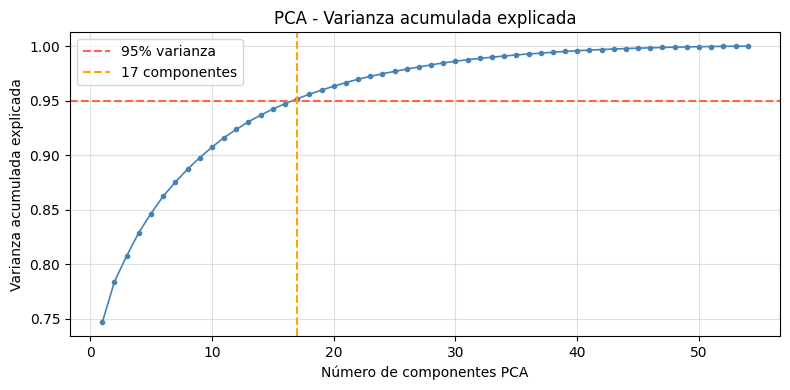

In [17]:
# Analisis de varianza acumulada con PCA para determinar el numero optimo de componentes
pca_full = PCA(random_state=14)
pca_full.fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Numero minimo de componentes para cubrir al menos el 95% de la varianza
n_95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Componentes para >=95% de varianza: {n_95} (de {X_train.shape[1]} originales)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='.', linewidth=1.2, color='steelblue')
ax.axhline(0.95, color='tomato', linestyle='--', label='95% varianza')
ax.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} componentes')
ax.set_xlabel('Número de componentes PCA')
ax.set_ylabel('Varianza acumulada explicada')
ax.set_title('PCA - Varianza acumulada explicada')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [18]:
# Transformacion PCA con el numero de componentes seleccionado
pca = PCA(n_components=n_95, random_state=14)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Shape train: {X_train_pca.shape}" )
print(f"Shape test: {X_test_pca.shape}")


Shape train: (136, 17)
Shape test: (34, 17)


### Entrenamiento - PCA

In [19]:
# Lista de modelos para entrenamiento con componentes PCA
models_pca = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'NN':            MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=14),
    'SVM':           SVC(kernel='rbf', C=1.0, random_state=14),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=14),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=14, n_jobs=-1),
}


In [20]:
# Entrenamiento y evaluacion con componentes PCA
results_pca = {}
for name, clf in models_pca.items():
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    results_pca[name] = {
        'acc':  accuracy_score(y_test, y_pred),
        'f1':   f1_score(y_test, y_pred, average='weighted'),
        'pred': y_pred,
    }
    print("-"*60)
    print(f"{name}  ({n_95} componentes PCA)")
    print("-"*60)
    print(classification_report(y_test, y_pred, target_names=['Casado', 'Divorciado']))


------------------------------------------------------------
KNN  (17 componentes PCA)
------------------------------------------------------------
              precision    recall  f1-score   support

      Casado       0.94      1.00      0.97        17
  Divorciado       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

------------------------------------------------------------
NN  (17 componentes PCA)
------------------------------------------------------------
              precision    recall  f1-score   support

      Casado       0.94      1.00      0.97        17
  Divorciado       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

---------------------------------------------------

### Evaluacion - PCA

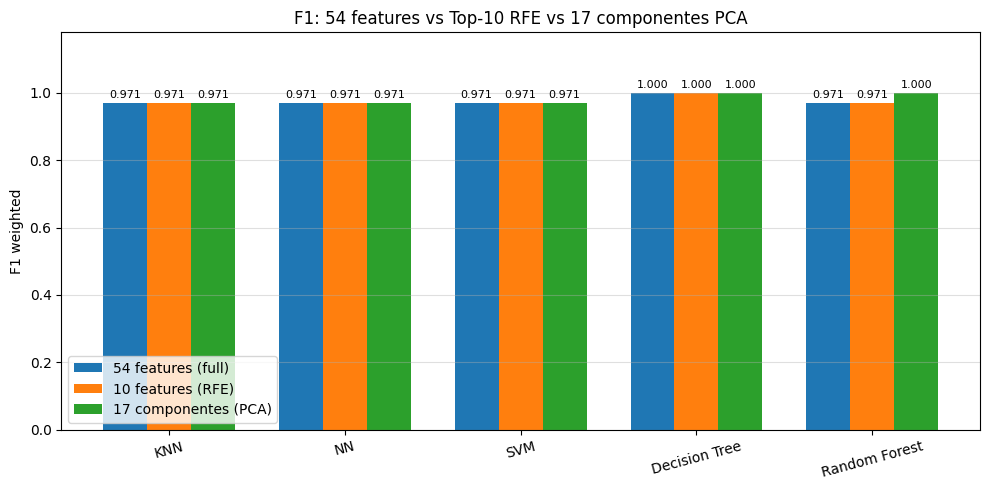

In [21]:
# Comparacion de F1: todas las features vs top 10 (RFE) vs componentes PCA
names    = list(results.keys())
f1_full  = [results[n]['f1']     for n in names]
f1_rfe   = [results_10[n]['f1']  for n in names]
f1_pca   = [results_pca[n]['f1'] for n in names]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width,  f1_full, width, label='54 features (full)')
bars2 = ax.bar(x,          f1_rfe,  width, label='10 features (RFE)')
bars3 = ax.bar(x + width,  f1_pca,  width, label=f'{n_95} componentes (PCA)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1.18)
ax.set_ylabel('F1 weighted')
ax.set_title(f'F1: 54 features vs Top-10 RFE vs {n_95} componentes PCA')
ax.legend()
for bars in (bars1, bars2, bars3):
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


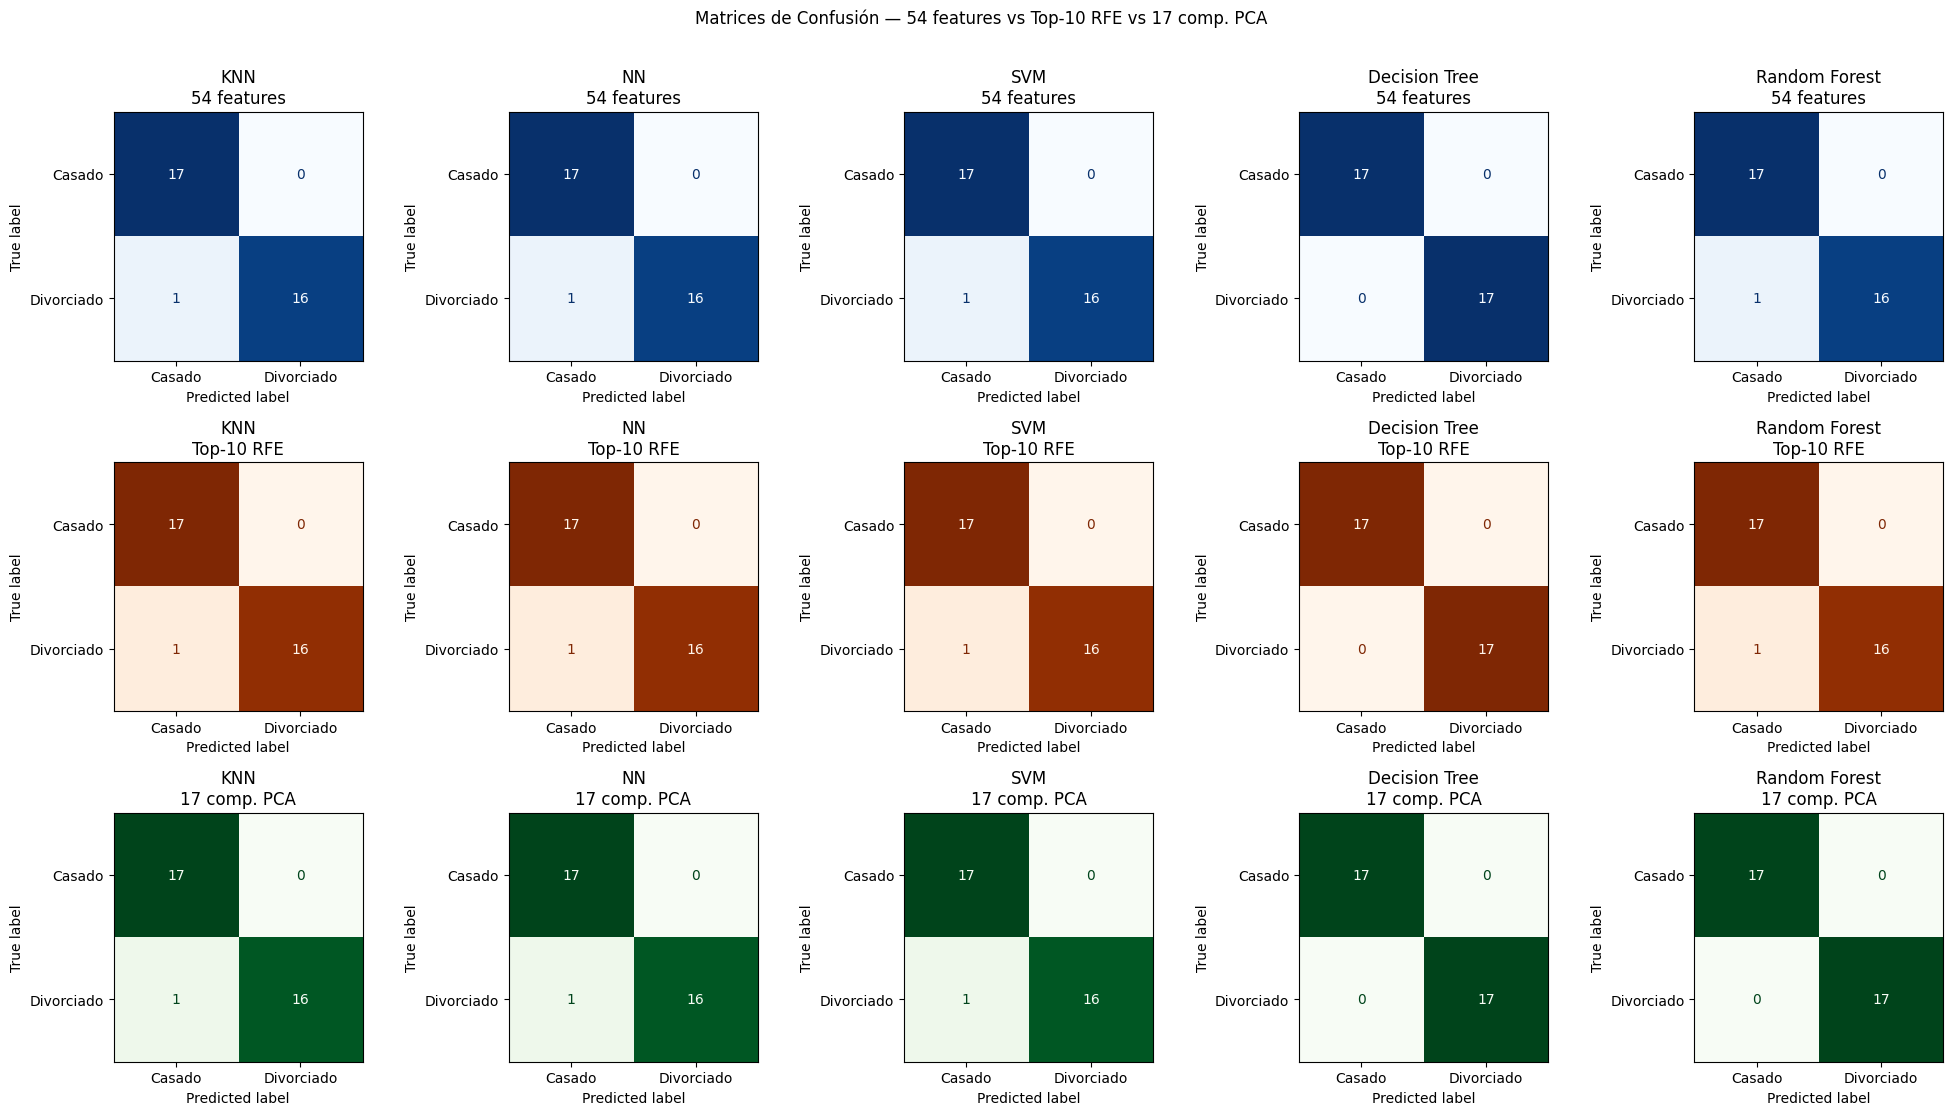

In [22]:
# Matrices de confusion: todas las features vs top 10 (RFE) vs componentes PCA
fig, axes = plt.subplots(3, len(names), figsize=(4 * len(names), 11))
for j, name in enumerate(names):
    cm_full = confusion_matrix(y_test, results[name]['pred'])
    ConfusionMatrixDisplay(cm_full, display_labels=['Casado', 'Divorciado']).plot(
        ax=axes[0, j], cmap='Blues', colorbar=False)
    axes[0, j].set_title(f'{name}\n54 features')

    cm_rfe = confusion_matrix(y_test, results_10[name]['pred'])
    ConfusionMatrixDisplay(cm_rfe, display_labels=['Casado', 'Divorciado']).plot(
        ax=axes[1, j], cmap='Oranges', colorbar=False)
    axes[1, j].set_title(f'{name}\nTop-10 RFE')

    cm_pca = confusion_matrix(y_test, results_pca[name]['pred'])
    ConfusionMatrixDisplay(cm_pca, display_labels=['Casado', 'Divorciado']).plot(
        ax=axes[2, j], cmap='Greens', colorbar=False)
    axes[2, j].set_title(f'{name}\n{n_95} comp. PCA')

plt.suptitle(f'Matrices de Confusión — 54 features vs Top-10 RFE vs {n_95} comp. PCA', y=1.01)
plt.tight_layout()
plt.show()


# Problema 5

Repita el problema 3 considerando el problema de pronóstico de `CarPrice_Assignment`.

### Librerias

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Carga de datos

In [24]:
# Descarga de datos
file = "CarPrice_Assignment.csv"

path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df5 = pd.read_csv(os.path.join(path, file))


In [25]:
df5.head()


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [26]:
df5.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

### Preprocesamiento de datos

In [27]:
# Eliminacion de columnas no relevantes para el modelo
cols_ignore = ['car_ID', 'symboling', 'CarName']
df5.drop(columns=cols_ignore, inplace=True)


In [28]:
# Revision de valores unicos en columnas categoricas
for col in df5.select_dtypes(include='object').columns:
    unique_values = df5[col].unique()
    print(f"{col}: {unique_values}")


fueltype: ['gas' 'diesel']
aspiration: ['std' 'turbo']
doornumber: ['two' 'four']
carbody: ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drivewheel: ['rwd' 'fwd' '4wd']
enginelocation: ['front' 'rear']
enginetype: ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
cylindernumber: ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
fuelsystem: ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [29]:
# One-Hot Encoding de variables categoricas
df5 = pd.get_dummies(df5, drop_first=True)

print(f"Shape después de one-hot encoding: {df5.shape}")
df5.head()


Shape después de one-hot encoding: (205, 43)


,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,fueltype_gas,aspiration_turbo,doornumber_two,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginelocation_rear,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0,True,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
3,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False


In [30]:
# Separacion de features y target
X5 = df5.drop(columns=['price']).values
y5 = df5['price'].values

feature_names_5 = df5.drop(columns=['price']).columns.tolist()
n_features_5 = X5.shape[1]
print(f"Número de features después de encoding: {n_features_5}")

# Escalamiento y division en entrenamiento / prueba
scaler5 = StandardScaler()
X5_scaled = scaler5.fit_transform(X5)

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5_scaled, y5, test_size=0.2, random_state=14
)


Número de features después de encoding: 42


### Entrenamiento - Baseline

In [31]:
# Lista de modelos de regresion
# Nota: SVR es sensible a la escala del target. Se usa TransformedTargetRegressor
# para escalar y automáticamente, evitando R² negativos.
models_5 = {
    'KNN':           KNeighborsRegressor(n_neighbors=5),
    'NN':            MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=2000,
                                  random_state=14),
    'SVR':           TransformedTargetRegressor(
                         regressor=SVR(kernel='rbf', C=100.0),
                         transformer=StandardScaler()
                     ),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=14),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12,
                                           random_state=14, n_jobs=-1),
}


In [32]:
# Entrenamiento y evaluacion de cada modelo de regresion
results_5 = {}
for name, model in models_5.items():
    model.fit(X5_train, y5_train)
    y_pred = model.predict(X5_test)
    results_5[name] = {
        'r2':   r2_score(y5_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y5_test, y_pred)),
        'mae':  mean_absolute_error(y5_test, y_pred),
        'pred': y_pred,
    }
    print("-"*20)
    print(name)
    print("-"*20)
    print(f"R2:   {results_5[name]['r2']:.4f}")
    print(f"RMSE: {results_5[name]['rmse']:.2f}")
    print(f"MAE:  {results_5[name]['mae']:.2f}")


--------------------
KNN
--------------------
R2:   0.7279
RMSE: 4961.73
MAE:  3162.32
--------------------
NN
--------------------
R2:   0.8588
RMSE: 3573.64
MAE:  2722.27
--------------------
SVR
--------------------
R2:   0.8507
RMSE: 3675.45
MAE:  2363.92
--------------------
Decision Tree
--------------------
R2:   0.9059
RMSE: 2917.89
MAE:  2100.18
--------------------
Random Forest
--------------------
R2:   0.9316
RMSE: 2488.01
MAE:  1877.88


/home/zamax/miniconda3/envs/micd/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Entrenamiento - Feature Selection

In [33]:
# Feature Selection con RFE usando RandomForest para rankear las caracteristicas
rfe_ranker_5 = RFE(
    estimator=RandomForestRegressor(n_estimators=200, max_depth=12, random_state=14, n_jobs=-1),
    n_features_to_select=1,
    step=1
)
rfe_ranker_5.fit(X5_train, y5_train)

# Calculo de importancia normalizada a partir del ranking
ranking_5 = pd.Series(rfe_ranker_5.ranking_, index=feature_names_5).sort_values()
importance_5 = (1 / ranking_5).sort_values(ascending=False)
importance_norm_5 = importance_5 / importance_5.sum()

top10_features_5 = ranking_5.head(10).index.tolist()
print(f"Top 10 características seleccionadas por RFE:\n{top10_features_5}")


Top 10 características seleccionadas por RFE:
['enginesize', 'curbweight', 'highwaympg', 'carwidth', 'horsepower', 'peakrpm', 'wheelbase', 'citympg', 'compressionratio', 'carheight']


In [34]:
# Subconjunto de datos con las top 10 features seleccionadas por RFE
top10_idx_5 = [feature_names_5.index(f) for f in top10_features_5]
X5_train_10 = X5_train[:, top10_idx_5]
X5_test_10  = X5_test[:, top10_idx_5]


In [35]:
# Lista de modelos para entrenamiento con top 10 features
models_5_10 = {
    'KNN':           KNeighborsRegressor(n_neighbors=5),
    'NN':            MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=2000,
                                  random_state=14),
    'SVR':           TransformedTargetRegressor(
                         regressor=SVR(kernel='rbf', C=100.0),
                         transformer=StandardScaler()
                     ),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=14),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12,
                                           random_state=14, n_jobs=-1),
}


In [36]:
# Entrenamiento y evaluacion con top 10 features
results_5_10 = {}
for name, clf in models_5_10.items():
    clf.fit(X5_train_10, y5_train)
    y_pred = clf.predict(X5_test_10)
    results_5_10[name] = {
        'r2':   r2_score(y5_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y5_test, y_pred)),
        'mae':  mean_absolute_error(y5_test, y_pred),
        'pred': y_pred,
    }
    print("-"*60)
    print(f"  {name}  (top 10 features)")
    print("-"*60)
    print(f"R2:   {results_5_10[name]['r2']:.4f}")
    print(f"RMSE: {results_5_10[name]['rmse']:.2f}")
    print(f"MAE:  {results_5_10[name]['mae']:.2f}")


------------------------------------------------------------
  KNN  (top 10 features)
------------------------------------------------------------
R2:   0.5908
RMSE: 6084.67
MAE:  3767.31
------------------------------------------------------------
  NN  (top 10 features)
------------------------------------------------------------
R2:   0.7870
RMSE: 4390.11
MAE:  3159.82
------------------------------------------------------------
  SVR  (top 10 features)
------------------------------------------------------------
R2:   0.7446
RMSE: 4806.69
MAE:  2484.63
------------------------------------------------------------
  Decision Tree  (top 10 features)
------------------------------------------------------------
R2:   0.9030
RMSE: 2962.18
MAE:  2087.37
------------------------------------------------------------
  Random Forest  (top 10 features)
------------------------------------------------------------
R2:   0.9305
RMSE: 2507.21
MAE:  1862.78


/home/zamax/miniconda3/envs/micd/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Evaluacion - Feature Selection

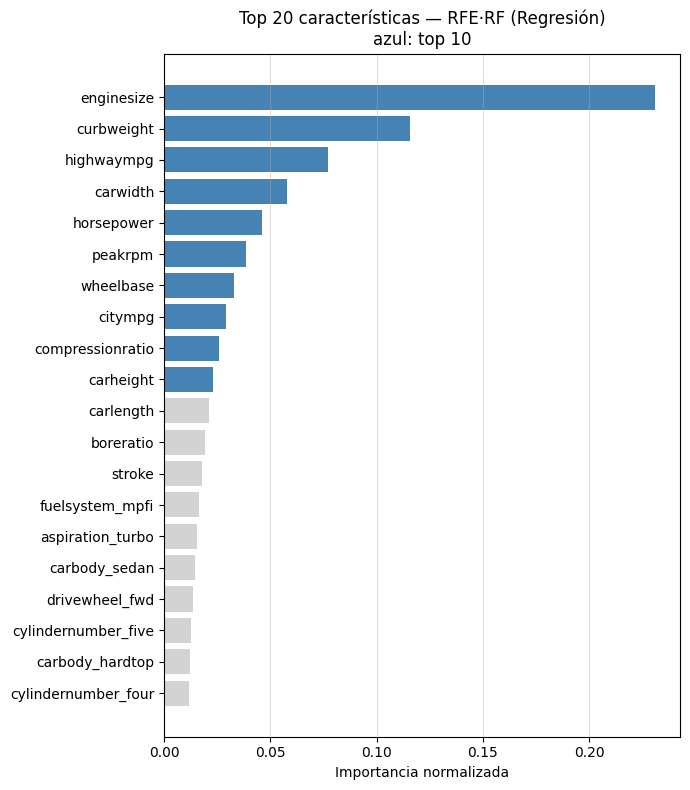

In [37]:
# Grafica de importancia normalizada de las top 20 features
top20_5 = importance_norm_5.head(20)
colors_5 = ['steelblue' if f in top10_features_5 else 'lightgray' for f in top20_5.index]

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(top20_5.index[::-1], top20_5.values[::-1], color=colors_5[::-1])
ax.set_xlabel('Importancia normalizada')
ax.set_title('Top 20 características — RFE·RF (Regresión)\nazul: top 10')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


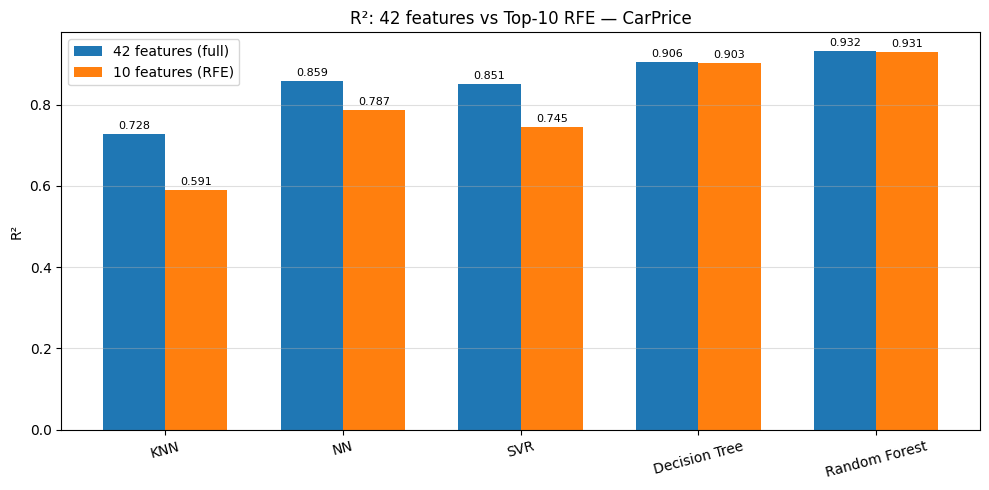

In [38]:
# Comparacion de R²: todas las features vs top 10 (RFE)
names_5  = list(results_5.keys())
r2_full  = [results_5[n]['r2']    for n in names_5]
r2_10    = [results_5_10[n]['r2'] for n in names_5]

x     = np.arange(len(names_5))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, r2_full, width, label=f'{n_features_5} features (full)')
bars2 = ax.bar(x + width/2, r2_10,   width, label='10 features (RFE)')
ax.set_xticks(x)
ax.set_xticklabels(names_5, rotation=15)
ax.set_ylabel('R²')
ax.set_title(f'R²: {n_features_5} features vs Top-10 RFE — CarPrice')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


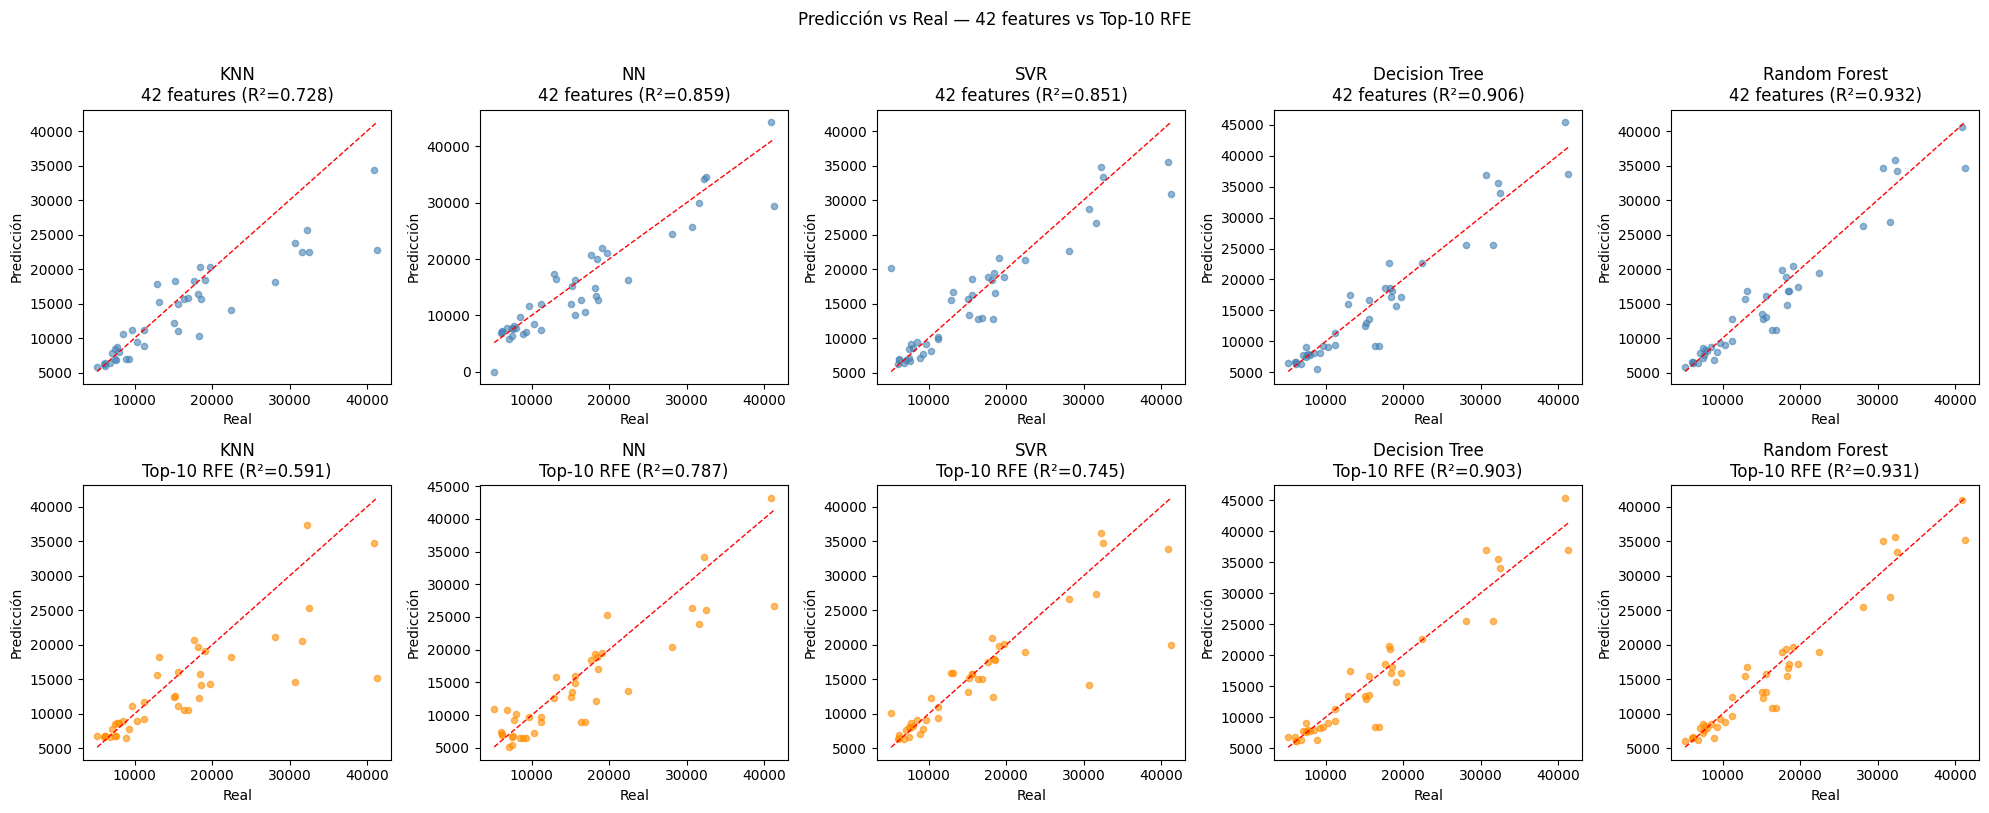

In [39]:
# Scatter plots: valor real vs prediccion — todas las features vs top 10 (RFE)
fig, axes = plt.subplots(2, len(names_5), figsize=(4 * len(names_5), 8))
for j, name in enumerate(names_5):
    axes[0, j].scatter(y5_test, results_5[name]['pred'], alpha=0.6, s=20, color='steelblue')
    axes[0, j].plot([y5_test.min(), y5_test.max()], [y5_test.min(), y5_test.max()],
                    'r--', linewidth=1)
    axes[0, j].set_title(f'{name}\n{n_features_5} features (R²={results_5[name]["r2"]:.3f})')
    axes[0, j].set_xlabel('Real')
    axes[0, j].set_ylabel('Predicción')

    axes[1, j].scatter(y5_test, results_5_10[name]['pred'], alpha=0.6, s=20, color='darkorange')
    axes[1, j].plot([y5_test.min(), y5_test.max()], [y5_test.min(), y5_test.max()],
                    'r--', linewidth=1)
    axes[1, j].set_title(f'{name}\nTop-10 RFE (R²={results_5_10[name]["r2"]:.3f})')
    axes[1, j].set_xlabel('Real')
    axes[1, j].set_ylabel('Predicción')

plt.suptitle(f'Predicción vs Real — {n_features_5} features vs Top-10 RFE', y=1.01)
plt.tight_layout()
plt.show()


# Problema 6

Repita el problema 4 considerando el problema de pronóstico de `CarPrice_Assignment`.

### Librerias

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Carga de datos

In [41]:
# Descarga de datos
file = "CarPrice_Assignment.csv"

path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df6 = pd.read_csv(os.path.join(path, file))

# Eliminacion de columnas no relevantes, One-Hot Encoding y escalamiento
cols_ignore = ['car_ID', 'symboling', 'CarName']
df6.drop(columns=cols_ignore, inplace=True)
df6 = pd.get_dummies(df6, drop_first=True)

X5 = df6.drop(columns=['price']).values
y5 = df6['price'].values
n_features_5 = X5.shape[1]

scaler5 = StandardScaler()
X5_scaled = scaler5.fit_transform(X5)

# Division en entrenamiento / prueba
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5_scaled, y5, test_size=0.2, random_state=14
)
print(f"Datos cargados: {df6.shape}, Train: {X5_train.shape}, Test: {X5_test.shape}")


Datos cargados: (205, 43), Train: (164, 42), Test: (41, 42)


### Preprocesamiento de datos

Componentes para >=95% de varianza: 20 (de 42 originales)


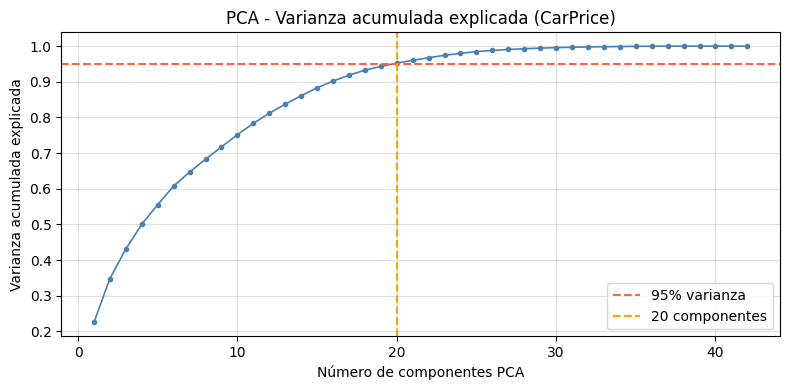

In [42]:
# Analisis de varianza acumulada con PCA para determinar el numero optimo de componentes
pca_full_5 = PCA(random_state=14)
pca_full_5.fit(X5_train)

cumvar_5 = np.cumsum(pca_full_5.explained_variance_ratio_)

# Numero minimo de componentes para cubrir al menos el 95% de la varianza
n_95_5 = int(np.argmax(cumvar_5 >= 0.95)) + 1
print(f"Componentes para >=95% de varianza: {n_95_5} (de {X5_train.shape[1]} originales)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar_5) + 1), cumvar_5, marker='.', linewidth=1.2, color='steelblue')
ax.axhline(0.95, color='tomato', linestyle='--', label='95% varianza')
ax.axvline(n_95_5, color='orange', linestyle='--', label=f'{n_95_5} componentes')
ax.set_xlabel('Número de componentes PCA')
ax.set_ylabel('Varianza acumulada explicada')
ax.set_title('PCA - Varianza acumulada explicada (CarPrice)')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [43]:
# Transformacion PCA con el numero de componentes seleccionado
pca_5 = PCA(n_components=n_95_5, random_state=14)
X5_train_pca = pca_5.fit_transform(X5_train)
X5_test_pca  = pca_5.transform(X5_test)

print(f"Shape train: {X5_train_pca.shape}" )
print(f"Shape test: {X5_test_pca.shape}")


Shape train: (164, 20)
Shape test: (41, 20)


### Entrenamiento - PCA

In [44]:
# Lista de modelos para entrenamiento con componentes PCA
models_5_pca = {
    'KNN':           KNeighborsRegressor(n_neighbors=5),
    'NN':            MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=2000, random_state=14),
    'SVR':           TransformedTargetRegressor(
                         regressor=SVR(kernel='rbf', C=100.0),
                         transformer=StandardScaler()
                     ),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=14),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12,
                                           random_state=14, n_jobs=-1),
}


In [45]:
# Entrenamiento y evaluacion con componentes PCA
results_5_pca = {}
for name, clf in models_5_pca.items():
    clf.fit(X5_train_pca, y5_train)
    y_pred = clf.predict(X5_test_pca)
    results_5_pca[name] = {
        'r2':   r2_score(y5_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y5_test, y_pred)),
        'mae':  mean_absolute_error(y5_test, y_pred),
        'pred': y_pred,
    }
    print("-"*60)
    print(f"{name} ({n_95_5} componentes PCA)")
    print("-"*60)
    print(f"R2:   {results_5_pca[name]['r2']:.4f}")
    print(f"RMSE: {results_5_pca[name]['rmse']:.2f}")
    print(f"MAE:  {results_5_pca[name]['mae']:.2f}")


------------------------------------------------------------
KNN (20 componentes PCA)
------------------------------------------------------------
R2:   0.7501
RMSE: 4754.93
MAE:  2956.89
------------------------------------------------------------
NN (20 componentes PCA)
------------------------------------------------------------
R2:   0.8646
RMSE: 3499.46
MAE:  2550.51
------------------------------------------------------------
SVR (20 componentes PCA)
------------------------------------------------------------
R2:   0.9001
RMSE: 3006.42
MAE:  2151.46
------------------------------------------------------------
Decision Tree (20 componentes PCA)
------------------------------------------------------------
R2:   0.4642
RMSE: 6962.39
MAE:  3463.17
------------------------------------------------------------
Random Forest (20 componentes PCA)
------------------------------------------------------------
R2:   0.8813
RMSE: 3276.52
MAE:  2221.13


/home/zamax/miniconda3/envs/micd/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Evaluacion - PCA

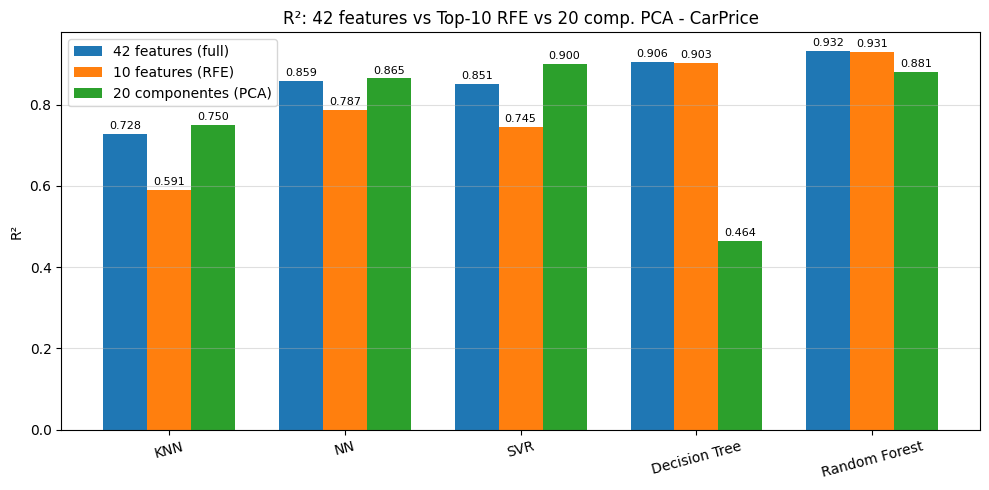

In [46]:
# Comparacion de R²: todas las features vs top 10 (RFE) vs componentes PCA
names_5   = list(results_5.keys())
r2_full_5 = [results_5[n]['r2']     for n in names_5]
r2_rfe_5  = [results_5_10[n]['r2']  for n in names_5]
r2_pca_5  = [results_5_pca[n]['r2'] for n in names_5]

x     = np.arange(len(names_5))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width,  r2_full_5, width, label=f'{n_features_5} features (full)')
bars2 = ax.bar(x,          r2_rfe_5,  width, label='10 features (RFE)')
bars3 = ax.bar(x + width,  r2_pca_5,  width, label=f'{n_95_5} componentes (PCA)')
ax.set_xticks(x)
ax.set_xticklabels(names_5, rotation=15)
ax.set_ylabel('R²')
ax.set_title(f'R²: {n_features_5} features vs Top-10 RFE vs {n_95_5} comp. PCA - CarPrice')
ax.legend()
for bars in (bars1, bars2, bars3):
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


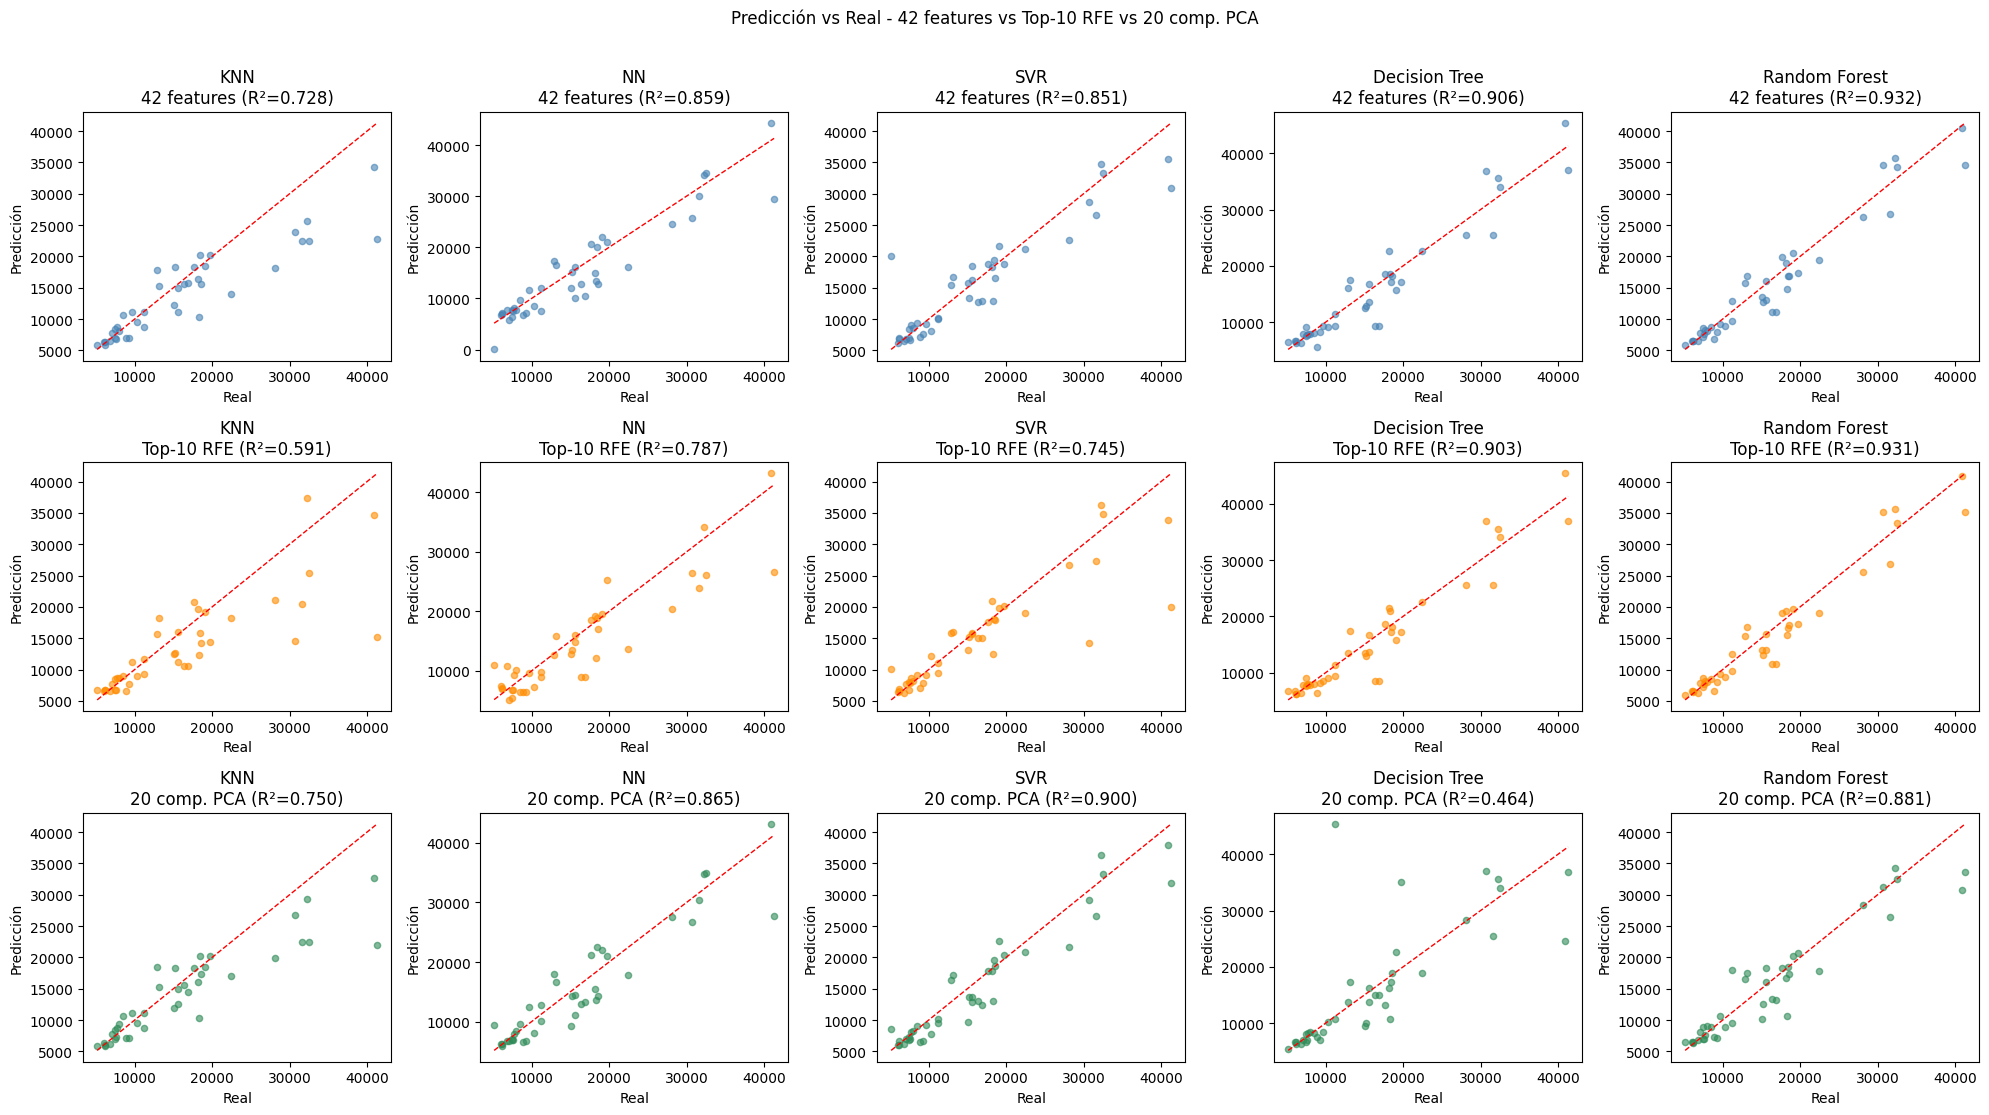

In [47]:
# Scatter plots: valor real vs prediccion — todas las features vs top 10 (RFE) vs PCA
fig, axes = plt.subplots(3, len(names_5), figsize=(4 * len(names_5), 11))
for j, name in enumerate(names_5):
    for row, (res, color, label) in enumerate([
        (results_5,     'steelblue',  f'{n_features_5} features'),
        (results_5_10,  'darkorange', 'Top-10 RFE'),
        (results_5_pca, 'seagreen',   f'{n_95_5} comp. PCA'),
    ]):
        ax = axes[row, j]
        ax.scatter(y5_test, res[name]['pred'], alpha=0.6, s=20, color=color)
        ax.plot([y5_test.min(), y5_test.max()], [y5_test.min(), y5_test.max()],
                'r--', linewidth=1)
        ax.set_title(f'{name}\n{label} (R²={res[name]["r2"]:.3f})')
        ax.set_xlabel('Real')
        ax.set_ylabel('Predicción')

plt.suptitle(f'Predicción vs Real - {n_features_5} features vs Top-10 RFE vs {n_95_5} comp. PCA',
             y=1.01)
plt.tight_layout()
plt.show()


# Problema 7

Utilice los algoritmos K-Means y DBSCAN para realizar compresión de imágenes por colores, como se explica en `Image Compression with K-means Clustering`. Anote todos sus supuestos, haga comparaciones y discuta sus hallazgos.

### Librerias

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import pairwise_distances_argmin
import warnings
warnings.filterwarnings('ignore')


### Carga de datos

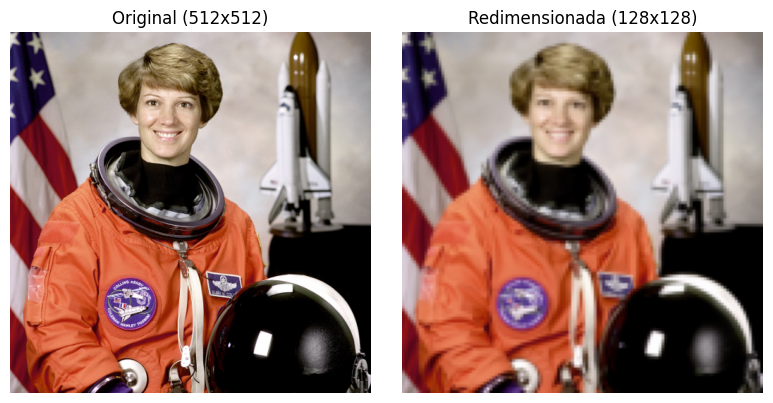

In [49]:
# Imagen astronaut de skimage, redimensionada a 128x128
image_full = data.astronaut()  # 512x512x3, uint8
A = transform.resize(image_full, (128, 128),
                     anti_aliasing=True,
                     preserve_range=True).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image_full)
ax[0].set_title('Original (512x512)')
ax[0].axis('off')
ax[1].imshow(A)
ax[1].set_title('Redimensionada (128x128)')
ax[1].axis('off')
plt.tight_layout()
plt.show()


### Preprocesamiento

In [50]:
# Aplanar pixeles a (N, 3) y normalizar al rango [0, 1]
h, w, c = A.shape
X_img = (A / 255.0).reshape(-1, 3)
print(f"Pixeles: {X_img.shape[0]}, Canales: {X_img.shape[1]}")


Pixeles: 16384, Canales: 3


### Entrenamiento - K-Means

In [51]:
# K-Means con K=16 colores
K = 16
km = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=14)
km.fit(X_img)

# Reconstruccion: cada pixel toma el color de su centroide
km_recon = km.cluster_centers_[km.labels_].reshape(h, w, c)
km_recon = np.clip(km_recon, 0, 1)


### Entrenamiento - DBSCAN

In [52]:
# DBSCAN sobre una muestra de 5000 pixeles (costo O(n^2) hace inviable usar todos)
rng = np.random.default_rng(14)
idx_sample = rng.choice(len(X_img), size=5000, replace=False)
X_sample = X_img[idx_sample]

eps = 0.01
db = DBSCAN(eps=eps, min_samples=5).fit(X_sample)
labels = db.labels_

# Centroides: promedio de pixeles en cada cluster (se ignora ruido label=-1)
valid_labels = [l for l in np.unique(labels) if l != -1]
centroids_db = np.array([X_sample[labels == l].mean(axis=0) for l in valid_labels])
print(f"DBSCAN eps={eps}: {len(valid_labels)} clusters encontrados")

# Asignar cada pixel de la imagen al centroide DBSCAN mas cercano
assigned = pairwise_distances_argmin(X_img, centroids_db)
db_recon = centroids_db[assigned].reshape(h, w, c)
db_recon = np.clip(db_recon, 0, 1)


DBSCAN eps=0.01: 42 clusters encontrados


### Evaluacion

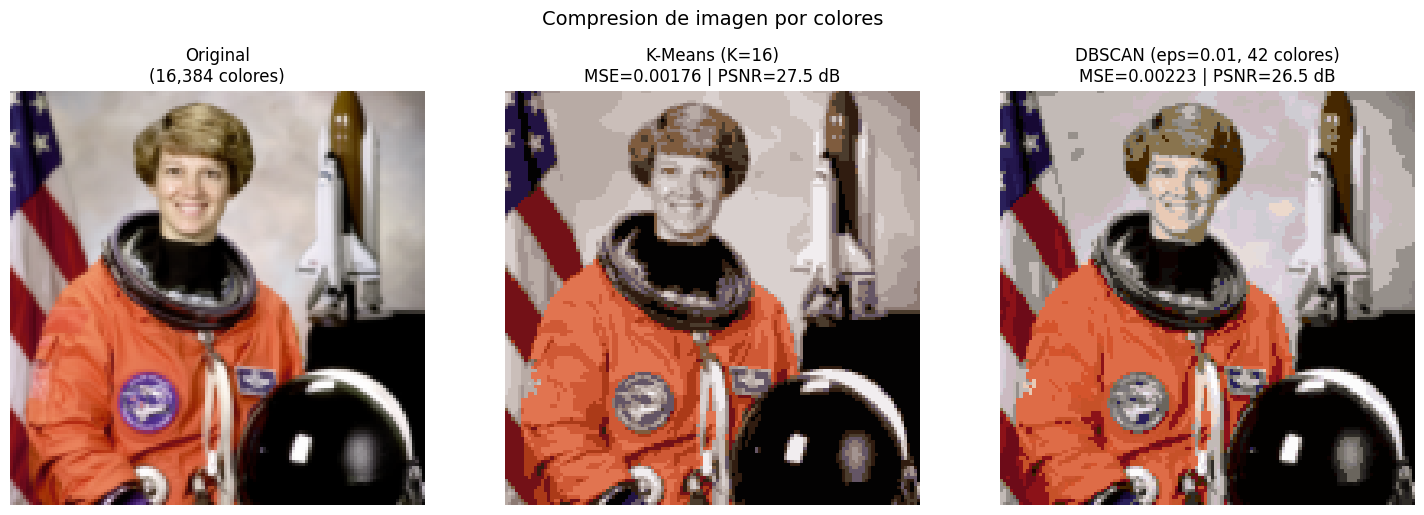

In [53]:
# Metricas: MSE y PSNR
mse_km = np.mean((X_img - km_recon.reshape(-1, 3)) ** 2)
psnr_km = 10 * np.log10(1.0 / mse_km)

mse_db = np.mean((X_img - db_recon.reshape(-1, 3)) ** 2)
psnr_db = 10 * np.log10(1.0 / mse_db)

# Visualizacion: original vs K-Means vs DBSCAN
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(X_img.reshape(h, w, c))
ax[0].set_title(f'Original\n({h*w:,} colores)')
ax[0].axis('off')

ax[1].imshow(km_recon)
ax[1].set_title(f'K-Means (K={K})\nMSE={mse_km:.5f} | PSNR={psnr_km:.1f} dB')
ax[1].axis('off')

ax[2].imshow(db_recon)
ax[2].set_title(f'DBSCAN (eps={eps}, {len(valid_labels)} colores)\nMSE={mse_db:.5f} | PSNR={psnr_db:.1f} dB')
ax[2].axis('off')

fig.suptitle('Compresion de imagen por colores', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Problema 8

¿Es K-Means demasiado sensible a los valores atípicos debido al operador de media? Averigüemos:

a) Construya un dataset con algunos valores atípicos que muestre qué tan sensible es K-Means.

b) Codifique un algoritmo de clustering K-Mediana, que es básicamente K-Means pero usa la mediana en lugar de la media.

c) Aplique su K-Mediana a sus datos. ¿Agrupa mejor?

Anote todos sus supuestos y discuta sus hallazgos.

### Librerias

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


### Carga de datos

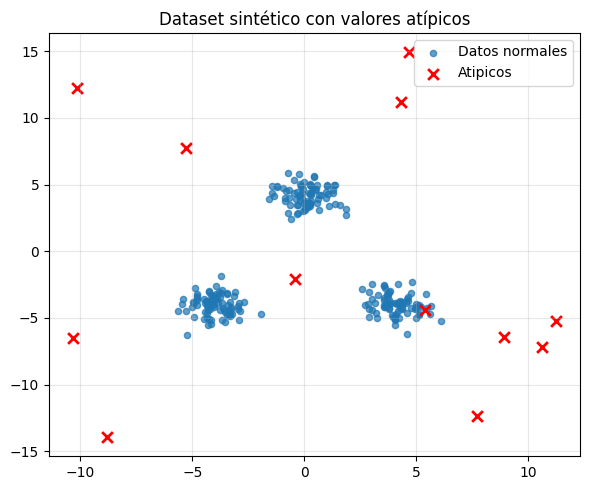

In [55]:
rng8 = np.random.default_rng(14)

# Tres grupos gaussianos bien separados con valores atipicos dispersos
centers = [(-4, -4), (0, 4), (4, -4)]
cluster_data = [rng8.multivariate_normal(c, np.eye(2) * 0.6, size=80) for c in centers]
X8_clean = np.vstack(cluster_data)
outliers = rng8.uniform(-15, 15, size=(12, 2))
X8 = np.vstack([X8_clean, outliers])

# Visualizacion del dataset sintetico
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X8_clean[:, 0], X8_clean[:, 1], s=20, alpha=0.7, label='Datos normales')
ax.scatter(outliers[:, 0], outliers[:, 1], s=60, marker='x', color='red', linewidths=2, label='Atipicos')
ax.set_title('Dataset sintético con valores atípicos')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Entrenamiento - K-Means

In [56]:
K8 = 3

# K-Means estandar: los centroides se calculan con la media, sensible a atipicos
km8 = KMeans(n_clusters=K8, init='k-means++', n_init=10, random_state=14)
km8.fit(X8)

labels_km8   = km8.labels_
centers_km8  = km8.cluster_centers_


### Entrenamiento - K-Mediana

In [57]:
def k_mediana(X, k, max_iter=300, tol=1e-4, random_state=None):
    """K-Means con mediana en lugar de media para mayor robustez ante atipicos."""
    rng = np.random.default_rng(random_state)

    # Inicializacion aleatoria de centroides
    idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[idx].copy()

    for _ in range(max_iter):
        # Asignacion y actualizacion iterativa usando la mediana del cluster
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)

        new_centroids = np.array([
            np.median(X[labels == j], axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])

        if np.max(np.linalg.norm(new_centroids - centroids, axis=1)) < tol:
            break
        centroids = new_centroids

    return labels, centroids


In [58]:
# Aplicacion de K-Mediana con los mismos parametros que K-Means
labels_kmed8, centers_kmed8 = k_mediana(X8, k=K8, random_state=14)


### Evaluacion

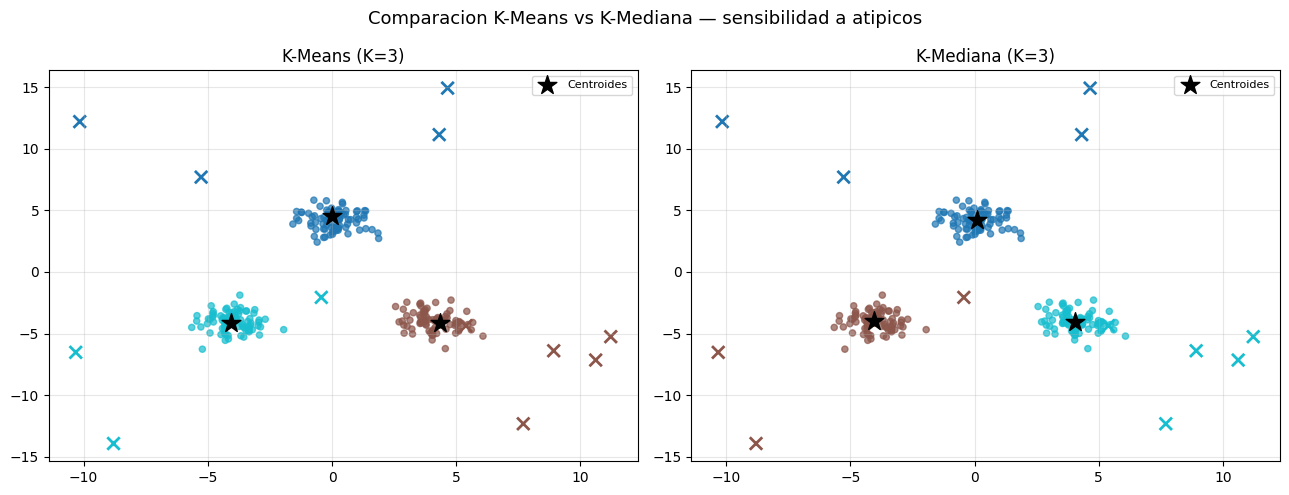

In [59]:
cmap8 = plt.get_cmap('tab10')
outlier_mask = np.zeros(len(X8), dtype=bool)
outlier_mask[len(X8_clean):] = True

# Comparacion visual de K-Means y K-Mediana con los atipicos resaltados
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, labels, est_centers, title in [
    (axes[0], labels_km8,   centers_km8,  f'K-Means (K={K8})'),
    (axes[1], labels_kmed8, centers_kmed8, f'K-Mediana (K={K8})'),
]:
    ax.scatter(X8[~outlier_mask, 0], X8[~outlier_mask, 1],
               c=labels[~outlier_mask], cmap=cmap8, vmin=0, vmax=K8-1,
               s=20, alpha=0.7)
    ax.scatter(X8[outlier_mask, 0], X8[outlier_mask, 1],
               c=labels[outlier_mask], cmap=cmap8, vmin=0, vmax=K8-1,
               s=80, marker='x', linewidths=2)
    ax.scatter(est_centers[:, 0], est_centers[:, 1],
               s=200, marker='*', color='black', zorder=5, label='Centroides')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Comparacion K-Means vs K-Mediana — sensibilidad a atipicos', fontsize=13)
plt.tight_layout()
plt.show()


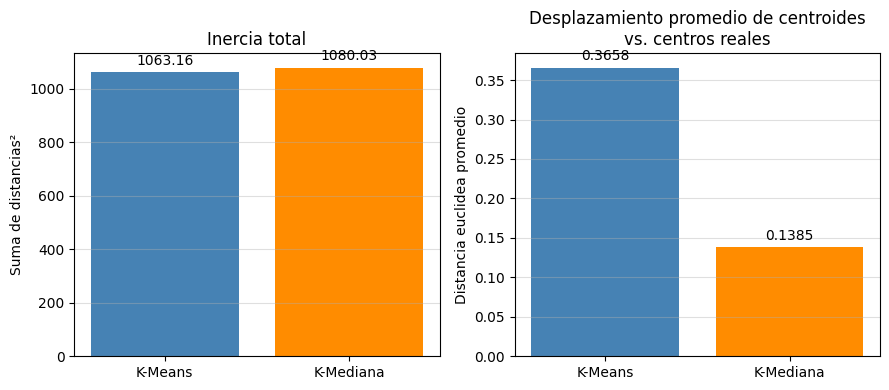

In [60]:
real_centers = np.array([(-4, -4), (0, 4), (4, -4)])

def dist_to_real(estimated, real):
    """Distancia euclidea promedio entre centroides estimados y reales (asignacion greedy)."""
    used = set()
    total = 0.0
    for ec in estimated:
        dists = [(np.linalg.norm(ec - rc), i) for i, rc in enumerate(real) if i not in used]
        d, idx = min(dists)
        used.add(idx)
        total += d
    return total / len(estimated)

# Calculo de inercia y desplazamiento de centroides para comparar ambos metodos
inertia_km  = sum(np.sum((X8[labels_km8   == j] - centers_km8[j])  ** 2) for j in range(K8))
inertia_kmd = sum(np.sum((X8[labels_kmed8 == j] - centers_kmed8[j]) ** 2) for j in range(K8))

disp_km  = dist_to_real(centers_km8,   np.array(centers))
disp_kmd = dist_to_real(centers_kmed8, np.array(centers))

# Grafica comparativa de inercia y desplazamiento
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

bars0 = ax[0].bar(['K-Means', 'K-Mediana'], [inertia_km, inertia_kmd], color=['steelblue', 'darkorange'])
ax[0].set_title('Inercia total')
ax[0].set_ylabel('Suma de distancias²')
ax[0].bar_label(bars0, fmt='%.2f', padding=3)
ax[0].grid(axis='y', alpha=0.4)

bars1 = ax[1].bar(['K-Means', 'K-Mediana'], [disp_km, disp_kmd], color=['steelblue', 'darkorange'])
ax[1].set_title('Desplazamiento promedio de centroides\nvs. centros reales')
ax[1].set_ylabel('Distancia euclidea promedio')
ax[1].bar_label(bars1, fmt='%.4f', padding=3)
ax[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()


# Problema 9

Considere el problema de predicción de género (`weight-height`). Haga lo siguiente:

1. Realice un proceso de clustering sobre las características considerando dos clusters. ¿Sus resultados se alinean con las etiquetas conocidas?

2. Intente identificar todos los valores atípicos.

3. Seleccione algunos datos aleatorios e invierta su etiqueta. Luego, intente identificar todos los valores atípicos. ¿Su método fue capaz de identificar exitosamente los datos invertidos?

Anote todos sus supuestos, haga comparaciones y discuta sus hallazgos.

### Librerias

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import kagglehub

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import adjusted_rand_score, accuracy_score


### Carga de datos

In [62]:
# Descarga de datos
file = "weight-height.csv"

path = kagglehub.dataset_download("krishnaraj30/weight-and-height-data-outlier-detection")
df9 = pd.read_csv(os.path.join(path, file))


In [63]:
df9.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [64]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


### Preprocesamiento

In [65]:
# Codificar genero: Female=0, Male=1
le9 = LabelEncoder()
y9_true = le9.fit_transform(df9['Gender'])

# Features: Height y Weight escalados
X9_raw = df9[['Height', 'Weight']].values
scaler9 = StandardScaler()
X9 = scaler9.fit_transform(X9_raw)

print(f"Shape: {X9.shape} | Clases: {le9.classes_}")


Shape: (10000, 2) | Clases: ['Female' 'Male']


### Entrenamiento - Clustering (K=2)

In [66]:
# K-Means con K=2 sobre datos de altura y peso (sin usar la etiqueta Gender)
km9 = KMeans(n_clusters=2, init='k-means++', n_init=20, random_state=14)
km9.fit(X9)
labels_km9 = km9.labels_

# Alinear clusters con etiquetas reales 
acc_direct  = accuracy_score(y9_true, labels_km9)
acc_swapped = accuracy_score(y9_true, 1 - labels_km9)
if acc_swapped > acc_direct:
    labels_km9 = 1 - labels_km9

ari9 = adjusted_rand_score(y9_true, labels_km9)
acc9 = accuracy_score(y9_true, labels_km9)
print(f"Accuracy vs etiquetas reales: {acc9:.4f}")
print(f"Adjusted Rand Index:          {ari9:.4f}")


Accuracy vs etiquetas reales: 0.8800
Adjusted Rand Index:          0.5776


### Evaluacion - Clustering

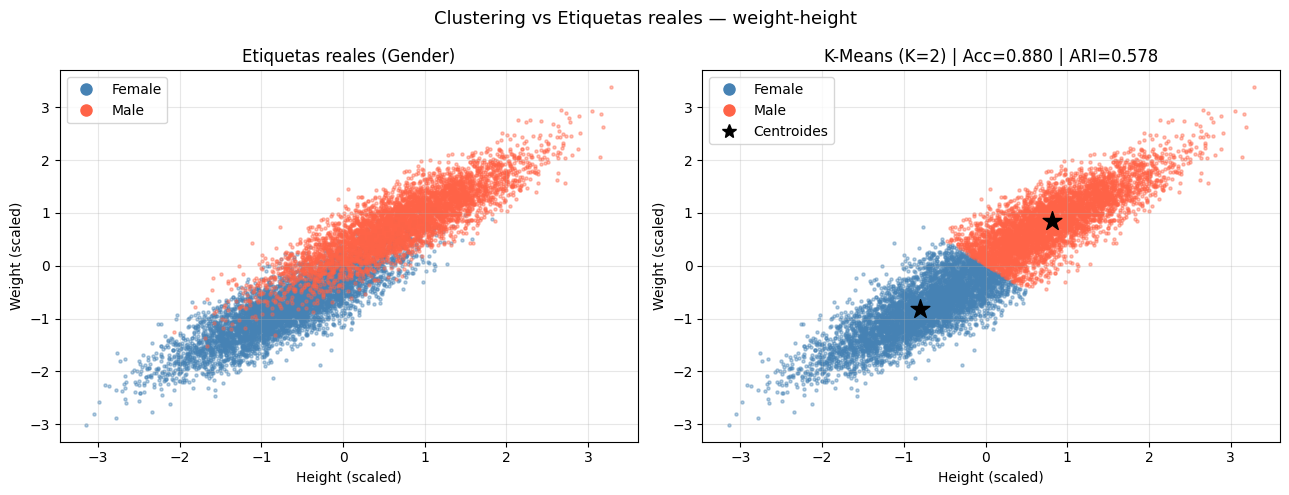

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_gender = {0: 'steelblue', 1: 'tomato'}
labels_gender = {0: 'Female', 1: 'Male'}

# Comparacion de etiquetas reales vs clusters obtenidos por K-Means
for ax, y_labels, title, show_centroids in [
    (axes[0], y9_true,    'Etiquetas reales (Gender)', False),
    (axes[1], labels_km9, f'K-Means (K=2) | Acc={acc9:.3f} | ARI={ari9:.3f}', True),
]:
    for g in [0, 1]:
        mask = y_labels == g
        ax.scatter(X9[mask, 0], X9[mask, 1],
                   color=colors_gender[g], s=5, alpha=0.4)

    if show_centroids:
        ax.scatter(km9.cluster_centers_[:, 0], km9.cluster_centers_[:, 1],
                   s=200, marker='*', color='black', zorder=5)

    handles = [
        mlines.Line2D([], [], color=colors_gender[g], marker='o', linestyle='None',
                      markersize=8, label=labels_gender[g])
        for g in [0, 1]
    ]
    if show_centroids:
        handles.append(
            mlines.Line2D([], [], color='black', marker='*', linestyle='None',
                          markersize=10, label='Centroides')
        )
    ax.legend(handles=handles)
    ax.set_xlabel('Height (scaled)')
    ax.set_ylabel('Weight (scaled)')
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.suptitle('Clustering vs Etiquetas reales — weight-height', fontsize=13)
plt.tight_layout()
plt.show()


### Deteccion de atipicos

In [68]:
# Isolation Forest para deteccion de atipicos (outliers)
iso = IsolationForest(contamination=0.01, random_state=14, n_jobs=-1)
iso_scores = iso.fit_predict(X9)
outlier_mask9 = iso_scores == -1

n_out = outlier_mask9.sum()
print(f"Atipicos detectados: {n_out} ({100*n_out/len(X9):.1f}%)")


Atipicos detectados: 100 (1.0%)


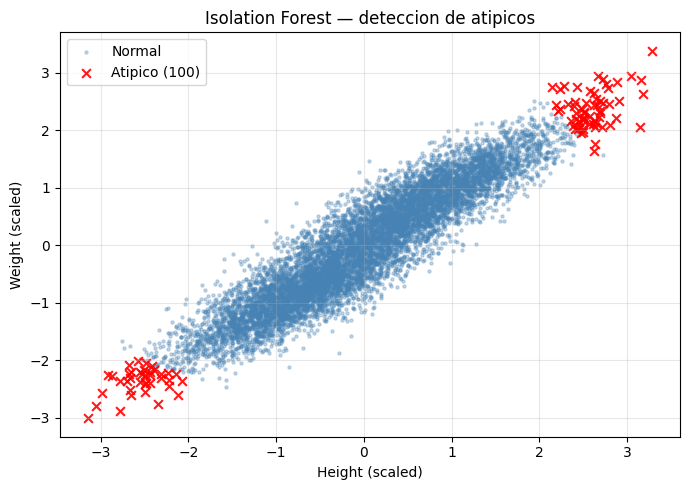

In [69]:
# Visualizacion de atipicos detectados en el espacio de altura y peso
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X9[~outlier_mask9, 0], X9[~outlier_mask9, 1],
           s=5, alpha=0.3, color='steelblue', label='Normal')
ax.scatter(X9[outlier_mask9, 0], X9[outlier_mask9, 1],
           s=40, alpha=0.9, color='red', marker='x', linewidths=1.5, label=f'Atipico ({n_out})')
ax.set_xlabel('Height (scaled)')
ax.set_ylabel('Weight (scaled)')
ax.set_title('Isolation Forest — deteccion de atipicos')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Evaluacion - Etiquetas invertidas

In [70]:
N_FLIP = 150
rng9 = np.random.default_rng(42)

# Seleccion aleatoria de puntos cuya etiqueta sera invertida
flip_idx = rng9.choice(len(X9), size=N_FLIP, replace=False)
flip_mask = np.zeros(len(X9), dtype=bool)
flip_mask[flip_idx] = True

# Deteccion de anomalias con Isolation Forest y umbral sobre el score
iso_flip = IsolationForest(contamination=float(N_FLIP / len(X9)) * 2,
                            random_state=14, n_jobs=-1)
iso_flip.fit(X9)
anomaly_score = -iso_flip.decision_function(X9)

threshold = np.percentile(anomaly_score, 100 * (1 - N_FLIP / len(X9)))
detected_mask = anomaly_score >= threshold

tp = (detected_mask & flip_mask).sum()
fp = (detected_mask & ~flip_mask).sum()
fn = (~detected_mask & flip_mask).sum()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Puntos invertidos: {N_FLIP}")
print(f"Detectados correctamente (TP): {tp}")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f}")


Puntos invertidos: 150
Detectados correctamente (TP): 5
Precision: 0.033 | Recall: 0.033


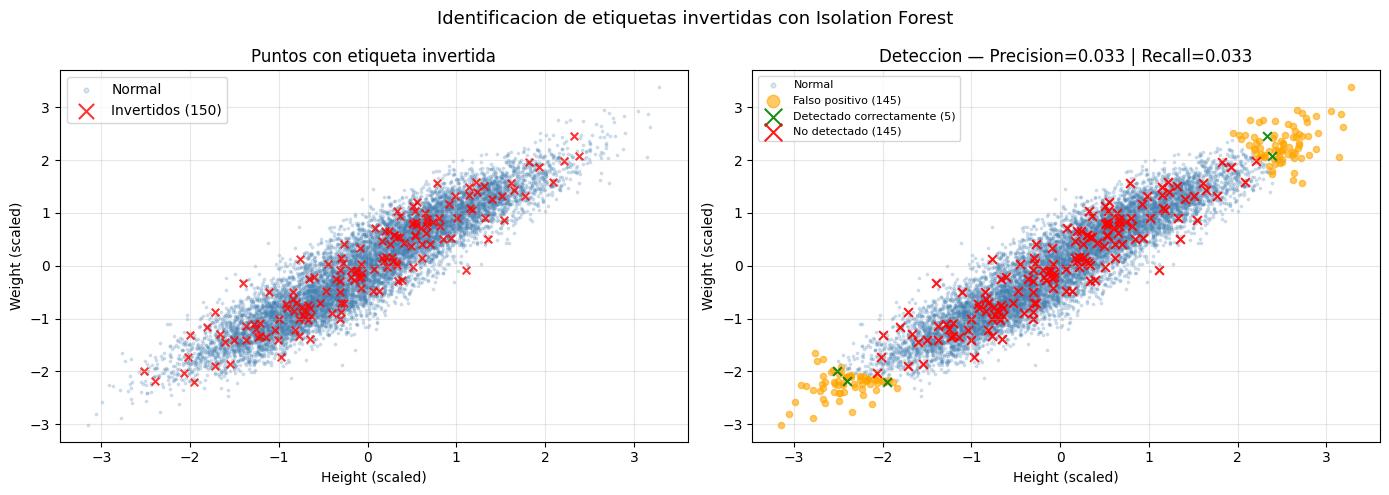

In [71]:
# Comparacion entre puntos invertidos y resultado de la deteccion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X9[~flip_mask, 0], X9[~flip_mask, 1],
                s=3, alpha=0.2, color='steelblue', label='Normal')
axes[0].scatter(X9[flip_mask, 0], X9[flip_mask, 1],
                s=30, alpha=0.8, color='red', marker='x',
                linewidths=1.5, label=f'Invertidos ({N_FLIP})')
axes[0].set_title('Puntos con etiqueta invertida')
axes[0].set_xlabel('Height (scaled)')
axes[0].set_ylabel('Weight (scaled)')
axes[0].legend(markerscale=2)
axes[0].grid(alpha=0.3)

correctly = detected_mask & flip_mask
missed    = ~detected_mask & flip_mask
false_pos = detected_mask & ~flip_mask

axes[1].scatter(X9[~detected_mask & ~flip_mask, 0], X9[~detected_mask & ~flip_mask, 1],
                s=3, alpha=0.2, color='steelblue', label='Normal')
axes[1].scatter(X9[false_pos, 0], X9[false_pos, 1],
                s=20, alpha=0.6, color='orange', label=f'Falso positivo ({fp})')
axes[1].scatter(X9[correctly, 0], X9[correctly, 1],
                s=40, alpha=0.9, color='green', marker='x',
                linewidths=1.5, label=f'Detectado correctamente ({tp})')
axes[1].scatter(X9[missed, 0], X9[missed, 1],
                s=40, alpha=0.9, color='red', marker='x',
                linewidths=1.5, label=f'No detectado ({fn})')
axes[1].set_title(f'Deteccion — Precision={precision:.3f} | Recall={recall:.3f}')
axes[1].set_xlabel('Height (scaled)')
axes[1].set_ylabel('Weight (scaled)')
axes[1].legend(markerscale=2, fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Identificacion de etiquetas invertidas con Isolation Forest', fontsize=13)
plt.tight_layout()
plt.show()
